> #### Environment Setup
> Copy the following line to the terminal
> ```cmd
> pip install matplotlib seaborn numpy scipy scikit-learn tensorflow yfinance
> ```

# Plan
1. Fetch Data
2. Generate All Candidate Features (technical indicators, returns, ratios, time)
3. Feature Selection — find the best feature subset by using lasso + elastic + correlation filter + rfecv voting and multi temporal window
4. Data Preparation — selected features, train/test split **before** scaling, RobustScaler
5. Build & Train LSTM — two LSTM layers with Dropout, EarlyStopping
6. Predict & Visualize
7. Evaluate — RMSE, MAE, MAPE

# 0. Configuration

In [1]:
%pip install matplotlib seaborn pandas numpy scipy scikit-learn tensorflow yfinance
import yfinance as yf
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

%pip install keras-tuner tensorboard -q
import keras_tuner as kt
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, Input
from keras.callbacks import EarlyStopping
import keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 6.7 MB/s eta 0:00:00


---
# 1. Fetching Stock Data

In [2]:
stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
stock_data

/tmp/ipykernel_11252/1204826036.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('TSLA', start='2016-01-01', multi_level_index=False)
[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2016-01-04,14.894000,15.425333,14.600000,15.381333,102406500
2016-01-05,14.895333,15.126000,14.666667,15.090667,47802000
2016-01-06,14.602667,14.670000,14.398667,14.666667,56686500
2016-01-07,14.376667,14.562667,14.244667,14.279333,53314500
2016-01-08,14.066667,14.696000,14.051333,14.524000,54421500
...,...,...,...,...,...
2026-06-12,406.429993,406.679993,386.760010,399.489990,63514500
2026-06-15,411.149994,416.000000,407.100006,412.369995,45620500
2026-06-16,404.660004,412.420013,400.540009,404.109985,40255500


---
# 2. Generate All Candidate Features

In [3]:
df = stock_data.copy()
# --- Technical indicators ---
for w in [5, 10, 20, 50]:
    df[f'EMA_{w}']    = df['Close'].ewm(span=w).mean()
    df[f'Volatility_{w}'] = df['Close'].pct_change().rolling(w).std()

df['RSI_14'] = 100 - 100 / (1 + df['Close'].diff().clip(lower=0).rolling(14).mean() /
                             df['Close'].diff().clip(upper=0).abs().rolling(14).mean())

ema12 = df['Close'].ewm(span=12).mean()
ema26 = df['Close'].ewm(span=26).mean()
df['MACD']         = ema12 - ema26
df['MACD_signal']  = df['MACD'].ewm(span=9).mean()
df['MACD_hist']    = df['MACD'] - df['MACD_signal']

sma20 = df['Close'].rolling(20).mean()
std20 = df['Close'].rolling(20).std()
df['BB_upper'] = sma20 + 2 * std20
df['BB_lower'] = sma20 - 2 * std20
df['BB_width'] = (df['BB_upper'] - df['BB_lower']) / sma20

high_low  = df['High'] - df['Low']
high_prev = (df['High'] - df['Close'].shift(1)).abs()
low_prev  = (df['Low']  - df['Close'].shift(1)).abs()
df['ATR_14'] = pd.concat([high_low, high_prev, low_prev], axis=1).max(axis=1).rolling(14).mean()

df['OBV'] = (np.sign(df['Close'].diff()) * df['Volume']).cumsum()

# --- Returns ---
df['log_return']   = np.log(df['Close'] / df['Close'].shift(1))
df['return_1d']    = df['Close'].pct_change()
df['return_5d']    = df['Close'].pct_change(5)

# --- Price ratios ---
df['high_low_ratio']  = df['High'] / df['Low']
df['close_open_ratio'] = df['Close'] / df['Open']

# --- Time features ---
# Year
year_days = df.index.is_leap_year * 366 + (~df.index.is_leap_year) * 365
df['sin_year'] = np.sin(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['cos_year'] = np.cos(2 * np.pi * (df.index.dayofyear - 1) / year_days)
df['day_of_week'] = df.index.dayofweek / 6.0

# Week (52 weeks)
df['sin_week'] = np.sin(2 * np.pi * (df.index.isocalendar().week - 1) / 52)
df['cos_week'] = np.cos(2 * np.pi * (df.index.isocalendar().week - 1) / 52)

# Month (12 months)
df['sin_month'] = np.sin(2 * np.pi * (df.index.month - 1) / 12)
df['cos_month'] = np.cos(2 * np.pi * (df.index.month - 1) / 12)

# Quarter (4 quarters)
df['sin_quarter'] = np.sin(2 * np.pi * (df.index.quarter - 1) / 4)
df['cos_quarter'] = np.cos(2 * np.pi * (df.index.quarter - 1) / 4)

# Linear trend feature
df = df.reset_index()  # Creates a 'Date' column with datetime values, numeric index
df['days_since_start'] = (df['Date'] - df['Date'].iloc[0]).dt.days.astype(float)

# --- Target ---
df['Close_nxt'] = df['Close'].shift(-1)
df = df.dropna()
df = df.drop(columns=['Date'])

feature_cols = [c for c in df.columns if c not in ['Close_nxt']]
target_col = ['Close_nxt']
print(f"{len(feature_cols)} candidate features:\n{feature_cols}")

37 candidate features:
['Close', 'High', 'Low', 'Open', 'Volume', 'EMA_5', 'Volatility_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'log_return', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'sin_year', 'cos_year', 'day_of_week', 'sin_week', 'cos_week', 'sin_month', 'cos_month', 'sin_quarter', 'cos_quarter', 'days_since_start']


---
# 3. Feature Selection

In [4]:
'''Sample split and Other Configuration'''
# Prepare data (using only features, not target)
X_temp = df[feature_cols].values
y = df[target_col].values

# Getting a sample of the data
sample_len = int(len(X_temp)*0.5)
X_sample = X_temp[:sample_len]
y_sample = y[:sample_len]
sample_df = df.iloc[:sample_len].copy()

print(X_sample.shape, y_sample.shape)

# Scale features (separate scaler for train/test)
scaler = RobustScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

(1289, 37) (1289, 1)


Before target filter, 37 features: ['Close', 'High', 'Low', 'Open', 'Volume', 'EMA_5', 'Volatility_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_hist', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'log_return', 'return_1d', 'return_5d', 'high_low_ratio', 'close_open_ratio', 'sin_year', 'cos_year', 'day_of_week', 'sin_week', 'cos_week', 'sin_month', 'cos_month', 'sin_quarter', 'cos_quarter', 'days_since_start']


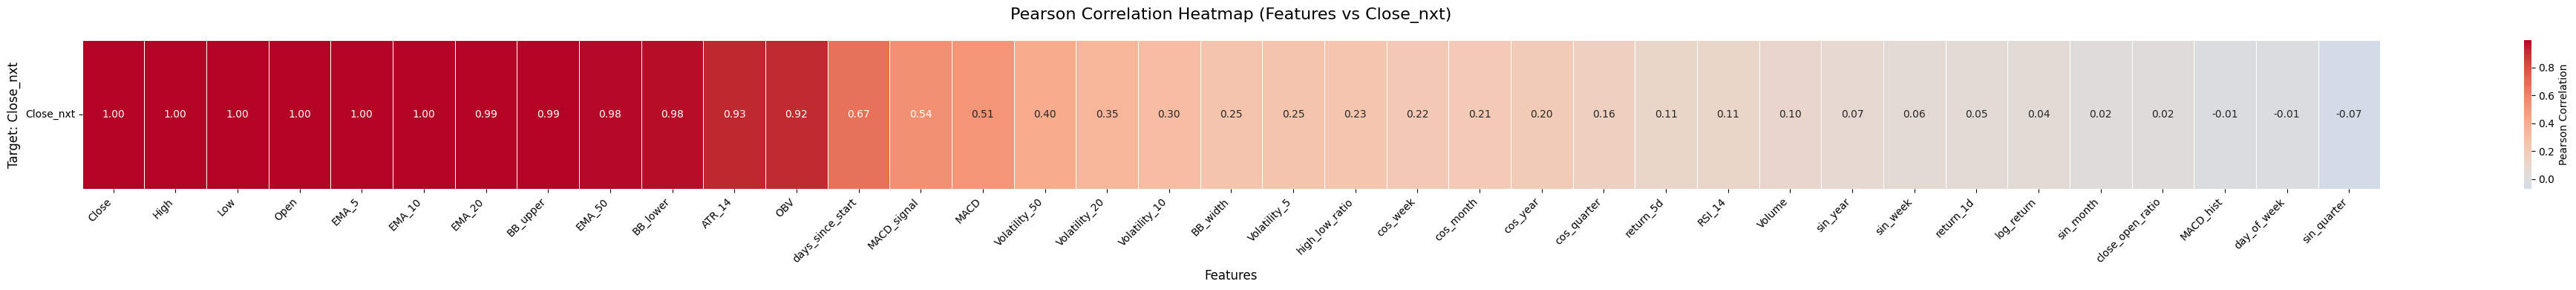

After target filter (>0.25): 20 features
['Close', 'High', 'Low', 'Open', 'EMA_5', 'Volatility_5', 'EMA_10', 'Volatility_10', 'EMA_20', 'Volatility_20', 'EMA_50', 'Volatility_50', 'MACD', 'MACD_signal', 'BB_upper', 'BB_lower', 'BB_width', 'ATR_14', 'OBV', 'days_since_start']


In [5]:
'''Correlation Map Visualization'''
TARGET_THRESHOLD = 0.25
print(f'Before target filter, {len(feature_cols)} features: {feature_cols}')
corr_matrix = sample_df[feature_cols + ['Close_nxt']].corr(method='pearson')
target_corr = corr_matrix['Close_nxt'].abs()
# Plot
plt.figure(figsize=(40, 4))
corr_matrix_for_display = corr_matrix[target_col].drop(target_col).sort_values(by=target_col[0], ascending=False).transpose()
sns.heatmap(corr_matrix_for_display, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.2f',
            linewidths=0.5,
            cbar_kws={'label': 'Pearson Correlation'})
plt.title("Pearson Correlation Heatmap (Features vs Close_nxt)", fontsize=16, pad=20)
plt.xlabel("Features", fontsize=12)
plt.ylabel("Target: Close_nxt", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# Create selected_features from correlation filter (matching attempt3.4)
selected_features = [f for f in feature_cols if target_corr[f] > TARGET_THRESHOLD]
print(f"After target filter (>{TARGET_THRESHOLD}): {len(selected_features)} features")

# Update feature cols
feature_cols = selected_features.copy()
print(feature_cols)

In [6]:
'''Selecting features with LASSO'''
# Update feature column and sample X dataset
selected_features.clear()
X_temp = df[feature_cols].values
X_sample = X_temp[:sample_len]
scaler = RobustScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

# Selecting features for the second time (using simple Lasso + GridSearchCV)
tscv = TimeSeriesSplit(n_splits=5)
# count how many times each feature gets a non‑zero coeff
selection_counts = np.zeros(len(feature_cols), dtype=int)
for train_idx, _ in tscv.split(X_sample_scaled):
    X_tr, y_tr = X_sample_scaled[train_idx], y[train_idx]
    
    # re‑scale inside each window to avoid leakage
    scaler = RobustScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    # Here we assume X is already scaled globally, or you
    X_tr_scaled = X_tr   

    lasso=Lasso(
            alpha=0.01,
            max_iter=10000,
            random_state=42
        )
    lasso.fit(X_tr_scaled, y_tr)

    selected = lasso.coef_ != 0
    selection_counts += selected.astype(int)

keep_mask = selection_counts >= (5 * 2/3)
selected_features = [feature_cols[i] for i, keep in enumerate(keep_mask) if keep]

# Update feature column
feature_cols = selected_features

---
# 4. Data Preparation (using selected features)
Split **before** scaling to prevent data leakage. Use separate scalers for input features and the target column.

### Train / Val / Test Split

| Split  | Slice                         | Rows              |
|--------|-------------------------------|-------------------|
| Train  | `df[:split_idx_train]`        | 70% of dataset    |
| Val    | `df[split_idx_train:split_idx_val]` | 15% of dataset    |
| Test   | `df[split_idx_val:]`          | 15% of dataset    |

In [7]:
LOOKBACK = 60
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
SEL_EPOCHS = 50
SEL_PATIENCE = 8

feature_cols = selected_features          # from forward selection above
if 'days_since_start' not in feature_cols:
    feature_cols.append('days_since_start')

split_idx_train = int(len(df) * TRAIN_RATIO)
split_idx_val = int(len(df) * (TRAIN_RATIO + VAL_RATIO))

train_features_raw = df[feature_cols].values[:split_idx_train]
val_features_raw = df[feature_cols].values[split_idx_train:split_idx_val] 
test_features_raw  = df[feature_cols].values[split_idx_val:]
train_target_raw   = df[target_col].values[:split_idx_train]
val_target_raw = df[target_col].values[split_idx_train:split_idx_val] 
test_target_raw    = df[target_col].values[split_idx_val:]

scaler = RobustScaler()
target_scaler  = RobustScaler()

# Scale train (fit + transform)
train_features = scaler.fit_transform(train_features_raw)
train_target = target_scaler.fit_transform(train_target_raw)
# Scale val and test (transform only - using train's statistics)
val_features = scaler.transform(val_features_raw)
val_target = target_scaler.transform(val_target_raw)
test_features = scaler.transform(test_features_raw)
test_target = target_scaler.transform(test_target_raw)

print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
print(f'Train: {train_features.shape}  Test: {test_features.shape}')

Feature columns (4): ['Close', 'BB_lower', 'BB_width', 'days_since_start']
Train: (1805, 4)  Test: (387, 4)


In [8]:
def create_sequences(features, target, lookback):
    X, y = [], []
    for i in range(lookback, len(features)):
        X.append(features[i - lookback:i])
        y.append(target[i, 0])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_features, train_target, LOOKBACK)
# For val: need padding from train
val_features_padded = np.concatenate([train_features[-LOOKBACK:], val_features])
val_target_padded = np.concatenate([train_target[-LOOKBACK:], val_target])
X_val, y_val = create_sequences(val_features_padded, val_target_padded, LOOKBACK)
# For test: need padding from val  
test_features_padded = np.concatenate([val_features[-LOOKBACK:], test_features])
test_target_padded = np.concatenate([val_target[-LOOKBACK:], test_target])
X_test, y_test = create_sequences(test_features_padded, test_target_padded, LOOKBACK)

print(f'X_train: {X_train.shape}  y_train: {y_train.shape}')
print(f'X_test : {X_test.shape}  y_test : {y_test.shape}')

X_train: (1745, 60, 4)  y_train: (1745,)
X_test : (387, 60, 4)  y_test : (387,)


---
# 5. Building and Training LSTM

In [9]:
# Define model builder for KerasTuner
def build_model(hp):
    model = Sequential([
        Input(shape=(LOOKBACK, X_train.shape[2])),
        LSTM(
            hp.Int('units1', min_value=32, max_value=128, step=32),
            return_sequences=True
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        LSTM(
            hp.Int('units2', min_value=32, max_value=128, step=32),
            return_sequences=False
        ),
        Dropout(hp.Float('dropout', min_value=0.1, max_value=0.3, step=0.1)),
        Dense(1)
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate', values=[0.001, 0.0005])
        ),
        loss='mse',
        metrics=['mae']
    )
    return model

# Run Hyperband search
tuner = kt.Hyperband(
    build_model,
    objective='val_loss',
    max_epochs=50,
    factor=3,
    hyperband_iterations=2,
    directory='kt_results',
    project_name='lstm_tuning'
)

# Search with early stopping
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1,
)

# Get best hyperparameters
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best Hyperparameters:')
print(f'  units1: {best_hp.get("units1")}')
print(f'  units2: {best_hp.get("units2")}')
print(f'  dropout: {best_hp.get("dropout")}')
print(f'  learning_rate: {best_hp.get("learning_rate")}')

Trial 89 Complete [00h 00m 38s]
val_loss: 0.007550516631454229

Best val_loss So Far: 0.004289841745048761
Total elapsed time: 00h 14m 48s
Best Hyperparameters:
  units1: 128
  units2: 96
  dropout: 0.1
  learning_rate: 0.001


In [10]:
# Build final model with best hyperparameters
model = Sequential([
    Input(shape=(LOOKBACK, X_train.shape[2])),
    LSTM(best_hp.get('units1'), return_sequences=True),
    Dropout(best_hp.get('dropout')),
    LSTM(best_hp.get('units2'), return_sequences=False),
    Dropout(best_hp.get('dropout')),
    Dense(1)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_hp.get('learning_rate')),
    loss='mse',
    metrics=['mae']
)

model.summary()

# Train final model
history = model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 128)        │        68,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 96)             │        86,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 154,593 (603.88 KB)

 Trainable params: 154,593 (603.88 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0339 - mae: 0.1030 - val_loss: 0.0268 - val_mae: 0.1265
Epoch 2/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0109 - mae: 0.0642 - val_loss: 0.0358 - val_mae: 0.1579
Epoch 3/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0077 - mae: 0.0522 - val_loss: 0.0141 - val_mae: 0.0910
Epoch 4/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0074 - mae: 0.0531 - val_loss: 0.0099 - val_mae: 0.0772
Epoch 5/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0057 - mae: 0.0468 - val_loss: 0.0097 - val_mae: 0.0769
Epoch 6/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0061 - mae: 0.0478 - val_loss: 0.0146 - val_mae: 0.0951
Epoch 7/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0059 - mae: 0.0467 - val_loss: 0.0250 - val_mae: 0.1339
Epoch 8/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0058 - mae: 0.0466 - val_loss: 0.0140 - val_mae: 0.0928
Epoch 9/100
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - lo

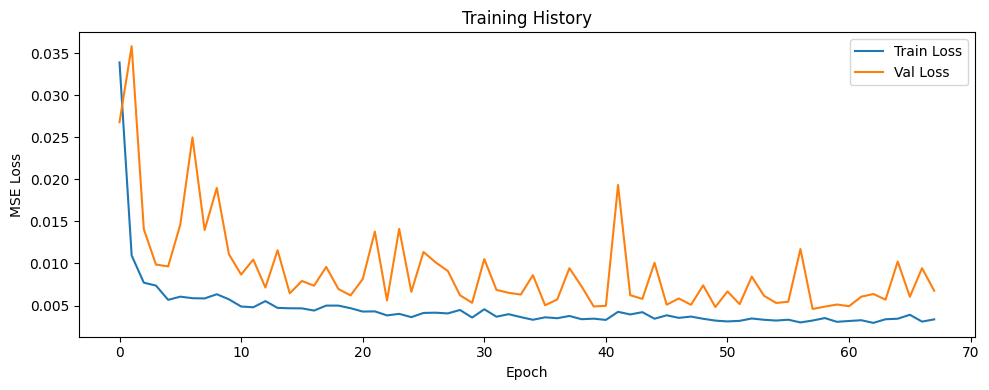

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Making Predictions

In [12]:
pred_scaled = model.predict(X_test)

prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

print(f'Predictions shape: {prediction.shape}')
print(f'Actuals shape     : {y_test_actual.shape}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Predictions shape: (387, 1)
Actuals shape     : (387, 1)


---
# 7. Visualisation

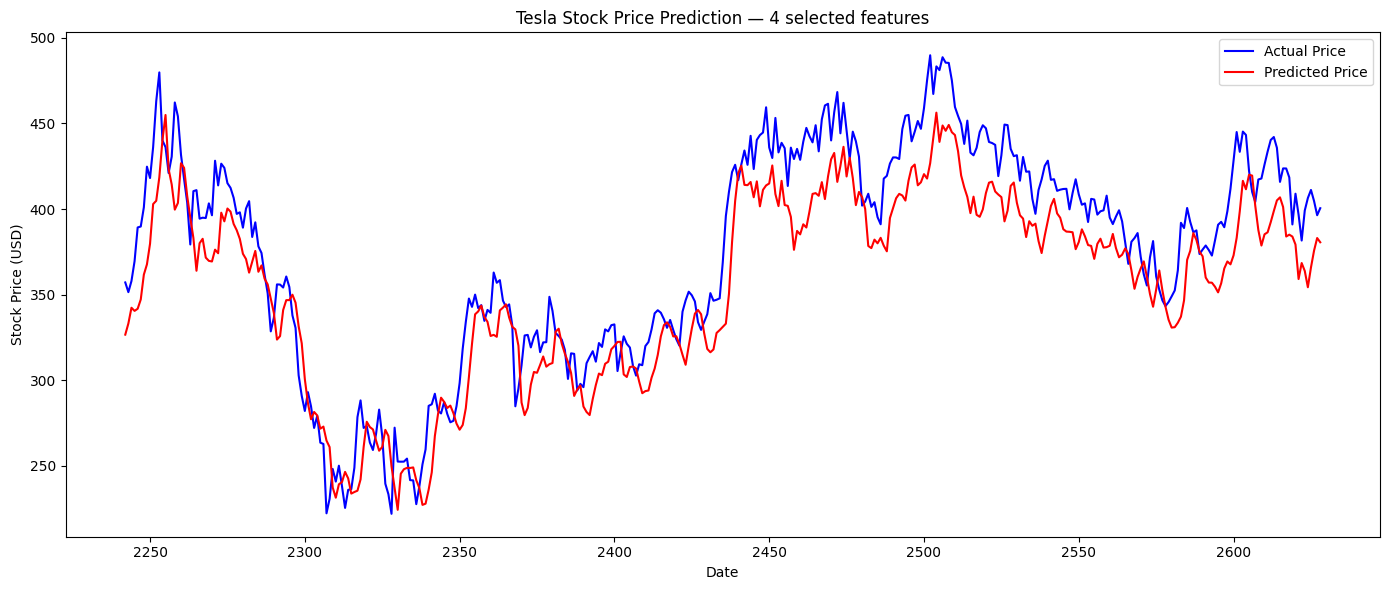

In [13]:
test_dates = df.index[split_idx_val:]

plt.figure(figsize=(14, 6))
plt.plot(test_dates, y_test_actual.flatten(), label='Actual Price', color='blue')
plt.plot(test_dates, prediction.flatten(), label='Predicted Price', color='red')
plt.title(f'Tesla Stock Price Prediction — {len(selected_features)} selected features')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

---
# 8. Model Evaluation

In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

print('=' * 55)
print(f'LSTM with Forward-Selected Features ({len(feature_cols)})')
print(f'Features: {feature_cols}')
print('=' * 55)
print(f'  MSE  : {mse:.4f}')
print(f'  RMSE : {rmse:.4f}')
print(f'  MAE  : {mae:.4f}')
print(f'  MAPE : {mape:.2f}%')
print('=' * 55)

LSTM with Forward-Selected Features (4)
Features: ['Close', 'BB_lower', 'BB_width', 'days_since_start']
  MSE  : 782.0999
  RMSE : 27.9660
  MAE  : 23.3675
  MAPE : 6.13%


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


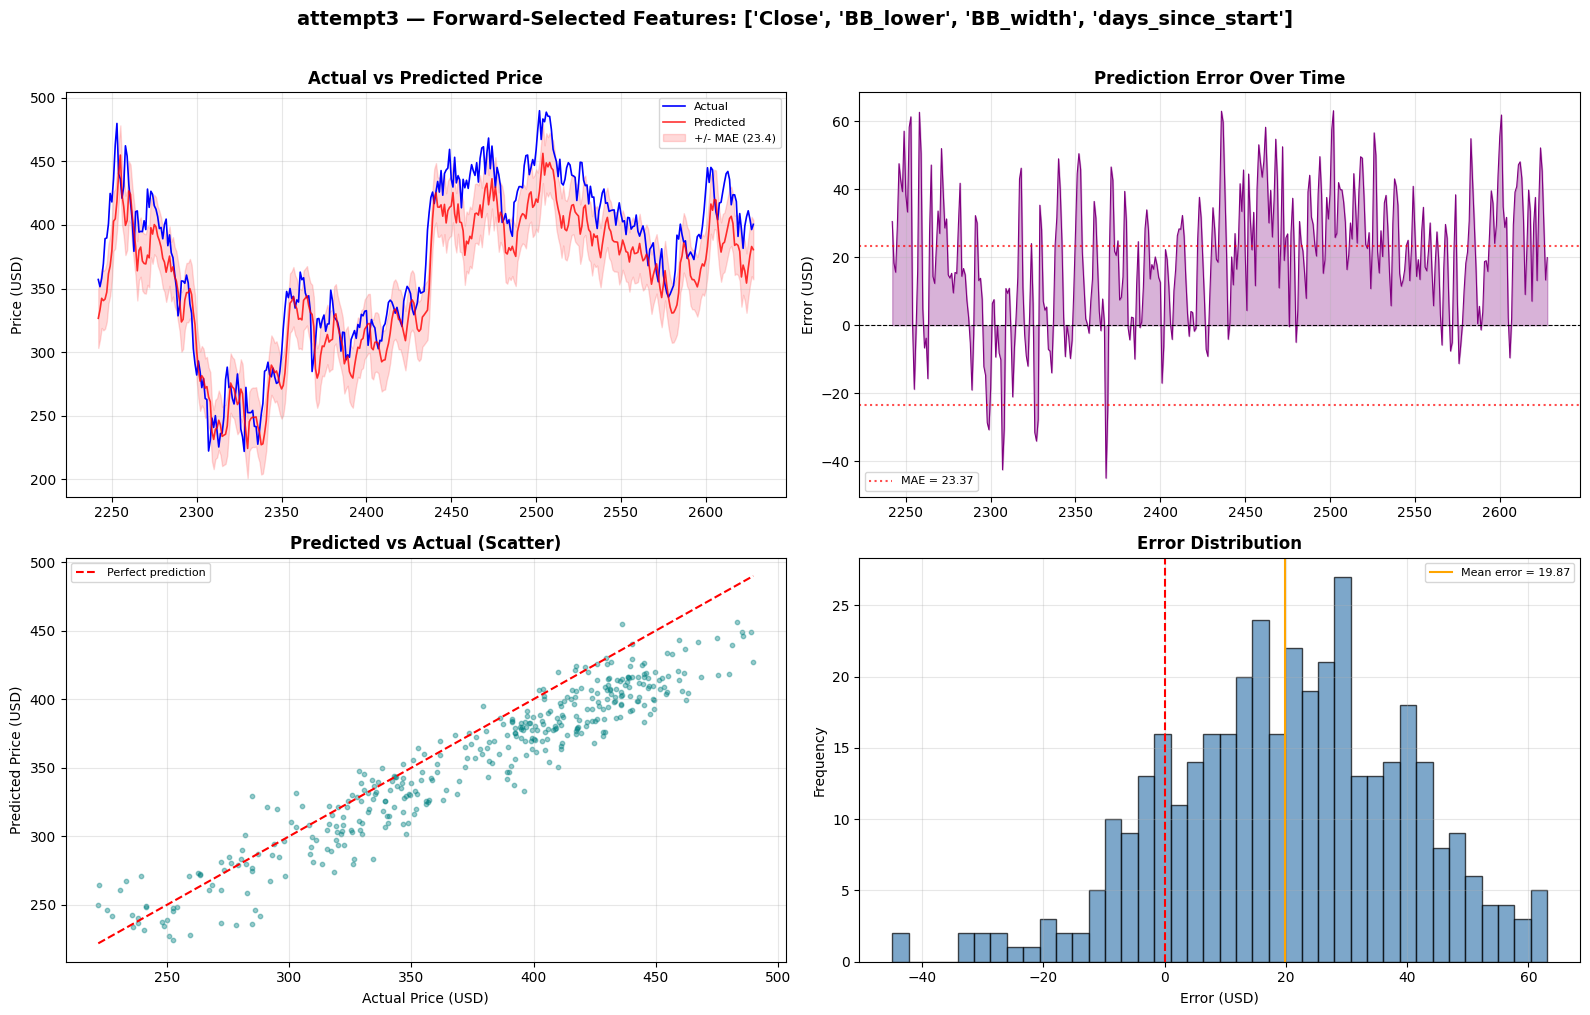

Mean Error: 19.8672  |  Std Error: 19.6824
Max Over-prediction: 63.0937  |  Max Under-prediction: -44.9411
Mean Abs % Error: 6.13%


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

pred_scaled = model.predict(X_test)
prediction = target_scaler.inverse_transform(pred_scaled)
y_test_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1))

mse  = mean_squared_error(y_test_actual, prediction)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_test_actual, prediction)
mape = np.mean(np.abs((y_test_actual - prediction) / y_test_actual)) * 100

errors = y_test_actual.flatten() - prediction.flatten()
pct_errors = (errors / y_test_actual.flatten()) * 100

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.plot(test_dates, y_test_actual.flatten(), label='Actual', color='blue', linewidth=1.2)
ax.plot(test_dates, prediction.flatten(), label='Predicted', color='red', linewidth=1.2, alpha=0.8)
ax.fill_between(test_dates, prediction.flatten() - mae, prediction.flatten() + mae,
                alpha=0.15, color='red', label=f'+/- MAE ({mae:.1f})')
ax.set_title('Actual vs Predicted Price', fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[0, 1]
ax.plot(test_dates, errors, color='purple', linewidth=0.8)
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.axhline(y=mae, color='red', linestyle=':', alpha=0.7, label=f'MAE = {mae:.2f}')
ax.axhline(y=-mae, color='red', linestyle=':', alpha=0.7)
ax.fill_between(test_dates, errors, 0, alpha=0.3, color='purple')
ax.set_title('Prediction Error Over Time', fontweight='bold')
ax.set_ylabel('Error (USD)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 0]
ax.scatter(y_test_actual.flatten(), prediction.flatten(), alpha=0.4, s=10, color='teal')
min_val = min(y_test_actual.min(), prediction.min())
max_val = max(y_test_actual.max(), prediction.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual Price (USD)')
ax.set_ylabel('Predicted Price (USD)')
ax.set_title('Predicted vs Actual (Scatter)', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1, 1]
ax.hist(errors, bins=40, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(x=0, color='red', linestyle='--', linewidth=1.5)
ax.axvline(x=errors.mean(), color='orange', linestyle='-', linewidth=1.5,
           label=f'Mean error = {errors.mean():.2f}')
ax.set_xlabel('Error (USD)')
ax.set_ylabel('Frequency')
ax.set_title('Error Distribution', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.suptitle(f'attempt3 — Forward-Selected Features: {feature_cols}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Mean Error: {errors.mean():.4f}  |  Std Error: {errors.std():.4f}')
print(f'Max Over-prediction: {errors.max():.4f}  |  Max Under-prediction: {errors.min():.4f}')
print(f'Mean Abs % Error: {np.abs(pct_errors).mean():.2f}%')